# Lab 4: Frequent Pattern Mining – Apriori Algorithm

**Name:** Amit Bhowmik  
**Department:** Computer Science and Engineering  
**ID:** 232031017  
**University:** Feni University

### Objectives
- Understand association rules
- Calculate support
- Calculate confidence
- Calculate lift
- Prepare transactional data for frequent pattern mining
- Apply the Apriori algorithm using `mlxtend`
- Generate and interpret association rules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid")

### Association Rule Mining

Association rule mining discovers relationships between items in transactional data.

A rule is written as:

**Antecedent → Consequent**

For example:

**{Milk, Bread} → {Butter}**

The rule means that transactions containing Milk and Bread may also contain Butter.

### Support

Support measures how frequently an itemset occurs in all transactions.

**Support(X) = Number of transactions containing X / Total number of transactions**

A higher support means the itemset occurs more frequently.

### Confidence

Confidence measures how often the consequent appears when the antecedent appears.

**Confidence(X → Y) = Support(X ∪ Y) / Support(X)**

A higher confidence means the rule is more reliable.

### Lift

Lift compares the observed occurrence of X and Y with the occurrence expected if they were independent.

**Lift(X → Y) = Confidence(X → Y) / Support(Y)**

- Lift > 1 → positive association
- Lift = 1 → approximately independent
- Lift < 1 → negative association

### Create Transaction Dataset

A small market-basket dataset is used so that the notebook can run independently without requiring an external CSV file.

In [2]:
transactions = [
    ["Milk", "Bread", "Butter"],
    ["Bread", "Diapers", "Beer", "Eggs"],
    ["Milk", "Bread", "Diapers", "Beer"],
    ["Bread", "Milk", "Diapers", "Beer"],
    ["Milk", "Bread", "Butter", "Eggs"],
    ["Bread", "Butter"],
    ["Milk", "Bread", "Diapers"],
    ["Bread", "Diapers", "Beer"],
    ["Milk", "Bread", "Butter"],
    ["Milk", "Diapers", "Beer", "Eggs"],
    ["Bread", "Milk", "Butter", "Diapers"],
    ["Bread", "Milk", "Beer"]
]

print("Number of transactions:", len(transactions))
print("First transaction:", transactions[0])

Number of transactions: 12
First transaction: ['Milk', 'Bread', 'Butter']


In [3]:
transaction_df = pd.DataFrame({
    "Transaction_ID": range(1, len(transactions) + 1),
    "Items": transactions
})

transaction_df

,Transaction_ID,Items
0,1,"[Milk, Bread, Butter]"
1,2,"[Bread, Diapers, Beer, Eggs]"
2,3,"[Milk, Bread, Diapers, Beer]"
3,4,"[Bread, Milk, Diapers, Beer]"
4,5,"[Milk, Bread, Butter, Eggs]"
5,6,"[Bread, Butter]"
6,7,"[Milk, Bread, Diapers]"
7,8,"[Bread, Diapers, Beer]"
8,9,"[Milk, Bread, Butter]"
9,10,"[Milk, Diapers, Beer, Eggs]"


### Convert Transactions into One-Hot Encoded Data

`TransactionEncoder` converts the transaction list into a Boolean matrix. Each row represents a transaction and each column represents an item.

In [4]:
te = TransactionEncoder()

encoded_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded_array,
    columns=te.columns_
)

basket

,Beer,Bread,Butter,Diapers,Eggs,Milk
0,False,True,True,False,False,True
1,True,True,False,True,True,False
2,True,True,False,True,False,True
3,True,True,False,True,False,True
4,False,True,True,False,True,True
5,False,True,True,False,False,False
6,False,True,False,True,False,True
7,True,True,False,True,False,False
8,False,True,True,False,False,True
9,True,False,False,True,True,True


### Item Frequency

Before applying Apriori, we can inspect how frequently each individual item occurs.

In [5]:
item_frequency = basket.sum().sort_values(ascending=False)

item_frequency

Bread      11
Milk        9
Diapers     7
Beer        6
Butter      5
Eggs        3
dtype: int64

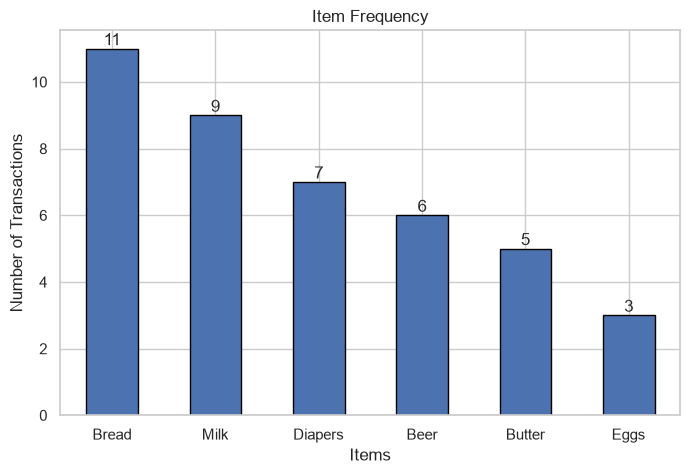

In [6]:
plt.figure(figsize=(8, 5))

ax = item_frequency.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Item Frequency")
plt.xlabel("Items")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.show()

### Apply Apriori Algorithm

The minimum support is set to **0.30**, meaning an itemset must occur in at least 30% of the transactions to be considered frequent.

In [7]:
min_support = 0.30

frequent_itemsets = apriori(
    basket,
    min_support=min_support,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets

,support,itemsets
0,0.916667,frozenset({Bread})
1,0.750000,frozenset({Milk})
2,0.666667,"frozenset({Milk, Bread})"
3,0.583333,frozenset({Diapers})
4,0.500000,"frozenset({Diapers, Bread})"
5,0.500000,frozenset({Beer})
6,0.416667,frozenset({Butter})
7,0.416667,"frozenset({Beer, Bread})"
8,0.416667,"frozenset({Butter, Bread})"
9,0.416667,"frozenset({Beer, Diapers})"


### Frequent Itemset Size

The `itemsets` column contains the discovered frequent itemsets. We can calculate their sizes and inspect how many itemsets were found at each level.

In [8]:
frequent_itemsets["itemset_size"] = frequent_itemsets["itemsets"].apply(len)

itemset_counts = (
    frequent_itemsets["itemset_size"]
    .value_counts()
    .sort_index()
)

itemset_counts

itemset_size
1    5
2    8
3    3
Name: count, dtype: int64

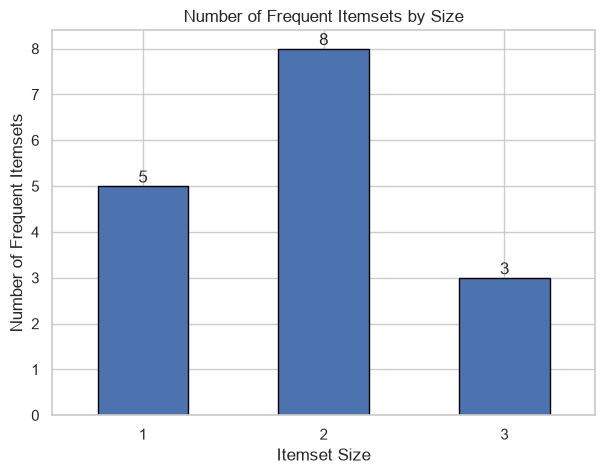

In [9]:
plt.figure(figsize=(7, 5))

ax = itemset_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Number of Frequent Itemsets by Size")
plt.xlabel("Itemset Size")
plt.ylabel("Number of Frequent Itemsets")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.show()

### Generate Association Rules

Association rules are generated from the frequent itemsets using **confidence** as the evaluation metric.

The minimum confidence is set to **0.60**.

In [10]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.60
)

rules = rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

,antecedents,consequents,support,confidence,lift
0,frozenset({Beer}),frozenset({Diapers}),0.416667,0.833333,1.428571
1,frozenset({Diapers}),frozenset({Beer}),0.416667,0.714286,1.428571
2,"frozenset({Beer, Bread})",frozenset({Diapers}),0.333333,0.800000,1.371429
3,"frozenset({Diapers, Bread})",frozenset({Beer}),0.333333,0.666667,1.333333
4,frozenset({Beer}),"frozenset({Diapers, Bread})",0.333333,0.666667,1.333333
5,frozenset({Butter}),"frozenset({Milk, Bread})",0.333333,0.800000,1.200000
6,frozenset({Butter}),frozenset({Bread}),0.416667,1.000000,1.090909
7,"frozenset({Milk, Butter})",frozenset({Bread}),0.333333,1.000000,1.090909
8,frozenset({Butter}),frozenset({Milk}),0.333333,0.800000,1.066667
9,"frozenset({Butter, Bread})",frozenset({Milk}),0.333333,0.800000,1.066667


### Format Association Rules

For easier reading, the antecedent and consequent itemsets are converted to strings.

In [11]:
rules_display = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules_display["antecedents"] = rules_display["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules_display["consequents"] = rules_display["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

rules_display["support"] = rules_display["support"].round(3)
rules_display["confidence"] = rules_display["confidence"].round(3)
rules_display["lift"] = rules_display["lift"].round(3)

rules_display

,antecedents,consequents,support,confidence,lift
0,Beer,Diapers,0.417,0.833,1.429
1,Diapers,Beer,0.417,0.714,1.429
2,"Beer, Bread",Diapers,0.333,0.800,1.371
3,"Bread, Diapers",Beer,0.333,0.667,1.333
4,Beer,"Bread, Diapers",0.333,0.667,1.333
5,Butter,"Bread, Milk",0.333,0.800,1.200
6,Butter,Bread,0.417,1.000,1.091
7,"Butter, Milk",Bread,0.333,1.000,1.091
8,Butter,Milk,0.333,0.800,1.067
9,"Bread, Butter",Milk,0.333,0.800,1.067


### Strong Association Rules

A strong rule can be selected using both confidence and lift. Here, we keep rules with confidence ≥ 0.60 and lift > 1.

In [12]:
strong_rules = rules_display[
    (rules_display["confidence"] >= 0.60) &
    (rules_display["lift"] > 1.0)
].copy()

strong_rules

,antecedents,consequents,support,confidence,lift
0,Beer,Diapers,0.417,0.833,1.429
1,Diapers,Beer,0.417,0.714,1.429
2,"Beer, Bread",Diapers,0.333,0.800,1.371
3,"Bread, Diapers",Beer,0.333,0.667,1.333
4,Beer,"Bread, Diapers",0.333,0.667,1.333
5,Butter,"Bread, Milk",0.333,0.800,1.200
6,Butter,Bread,0.417,1.000,1.091
7,"Butter, Milk",Bread,0.333,1.000,1.091
8,Butter,Milk,0.333,0.800,1.067
9,"Bread, Butter",Milk,0.333,0.800,1.067


### Top Rules by Lift

Rules with higher lift indicate stronger positive association between the antecedent and consequent.

In [13]:
top_rules = rules_display.sort_values(
    by="lift",
    ascending=False
).head(10)

top_rules

,antecedents,consequents,support,confidence,lift
0,Beer,Diapers,0.417,0.833,1.429
1,Diapers,Beer,0.417,0.714,1.429
2,"Beer, Bread",Diapers,0.333,0.800,1.371
3,"Bread, Diapers",Beer,0.333,0.667,1.333
4,Beer,"Bread, Diapers",0.333,0.667,1.333
5,Butter,"Bread, Milk",0.333,0.800,1.200
6,Butter,Bread,0.417,1.000,1.091
7,"Butter, Milk",Bread,0.333,1.000,1.091
8,Butter,Milk,0.333,0.800,1.067
9,"Bread, Butter",Milk,0.333,0.800,1.067


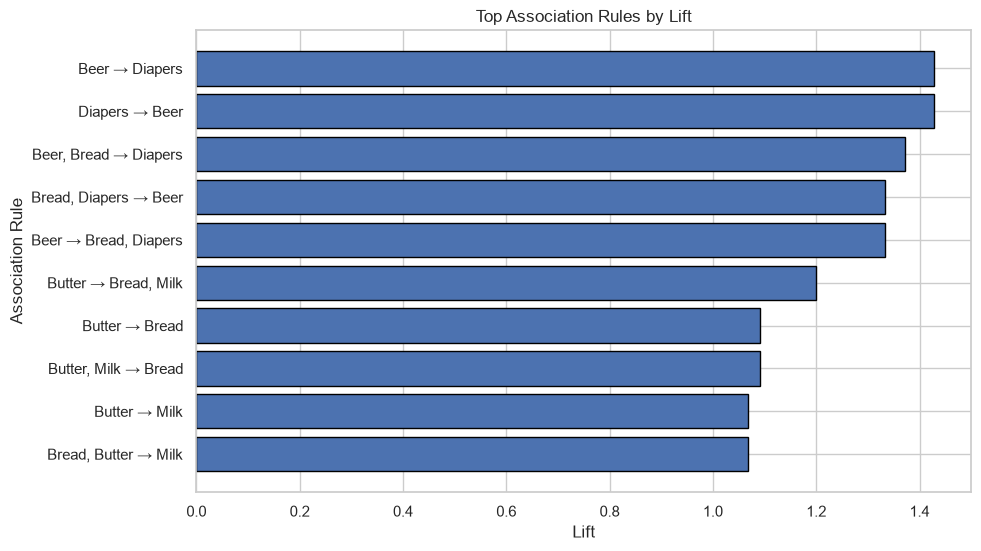

In [14]:
plt.figure(figsize=(10, 6))

rule_labels = (
    top_rules["antecedents"]
    + " → "
    + top_rules["consequents"]
)

plt.barh(
    rule_labels,
    top_rules["lift"],
    edgecolor="black"
)

plt.title("Top Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.gca().invert_yaxis()

plt.show()

### Interpretation

- **Support** tells us how common an itemset is in the complete transaction database.
- **Confidence** tells us how often the consequent occurs when the antecedent occurs.
- **Lift** tells us whether the two sides of a rule occur together more often than expected under independence.
- A lift greater than 1 indicates a positive association.

### Conclusion

The Apriori algorithm was successfully applied to transactional data using `mlxtend`. Frequent itemsets were identified using minimum support, and association rules were generated using confidence. The support, confidence, and lift measures were then used to evaluate the strength of the discovered rules.